In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
arquivo = files.upload()

Saving boa.jpg to boa.jpg
Saving clara.jpg to clara.jpg
Saving escura.jpg to escura.jpg


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def analisar_imagem(img_path, operacao, params=None):
    # carrega a imagem e converter para tons de cinza
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f"Erro: Imagem {img_path} não encontrada.")
        return
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # aplica a operação escolhida
    img_out = img_gray.copy()
    if operacao == 'expansao':
        img_out = cv2.normalize(img_gray, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
    elif operacao == 'equalizacao':
        img_out = cv2.equalizeHist(img_gray)
    elif operacao == 'gamma':
        gamma = params.get('gamma', 1.0)
        invGamma = 1.0 / gamma
        table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
        img_out = cv2.LUT(img_gray, table)

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    # imagens
    axs[0, 0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
    axs[0, 0].set_title('Antes (Original)')
    axs[0, 0].axis('off')

    axs[0, 1].imshow(img_out, cmap='gray', vmin=0, vmax=255)
    axs[0, 1].set_title(f'Depois ({operacao.capitalize()})')
    axs[0, 1].axis('off')

    # histogramas
    axs[1, 0].hist(img_gray.ravel(), 256, [0,256], color='black')
    axs[1, 0].set_title('Histograma - Antes')

    axs[1, 1].hist(img_out.ravel(), 256, [0,256], color='black')
    axs[1, 1].set_title('Histograma - Depois')

    plt.tight_layout()
    plt.show()

# Imagem 1 - Escura
2. Diagnóstico: As intensidades estão concentradas do lado esquerdo do histograma (tons próximos a 0), o que indica uma imagem subexposta (muitos pixels escuros e falta de detalhes nas sombras).
3. Operação Escolhida: Correção de Gamma. Justificativa: Como a imagem está globalmente escura, usar um gamma menor que 1 (ex: γ = 0.4) "estica" as intensidades baixas, revelando detalhes escondidos nas sombras sem estourar as partes claras.

/tmp/ipykernel_495/1729679174.py:40: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 0].hist(img_gray.ravel(), 256, [0,256], color='black')
/tmp/ipykernel_495/1729679174.py:43: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 1].hist(img_out.ravel(), 256, [0,256], color='black')


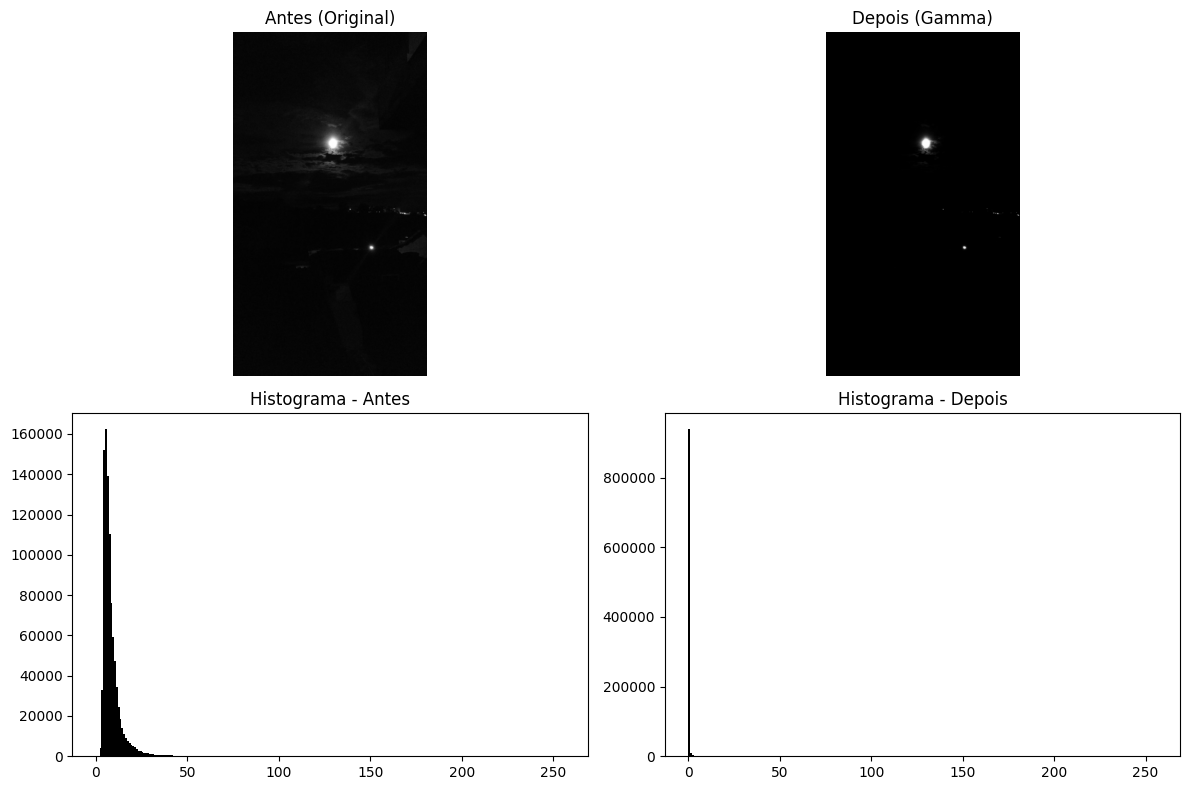

In [5]:
# Substitua 'escura.jpg' pelo nome do seu arquivo
analisar_imagem('escura.jpg', operacao='gamma', params={'gamma': 0.4})

# Imagem 2 - Clara
2. Diagnóstico: As intensidades estão concentradas do lado direito do histograma (tons próximos a 255), indicando superexposição e perda de detalhes nas áreas iluminadas.
3. Operação Escolhida: Equalização de Histograma (ou Correção de Gamma com γ > 1). Justificativa: A equalização ajuda a redistribuir os pixels acumulados nas altas intensidades por todo o espectro, recuperando o contraste global.

/tmp/ipykernel_495/1729679174.py:40: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 0].hist(img_gray.ravel(), 256, [0,256], color='black')
/tmp/ipykernel_495/1729679174.py:43: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 1].hist(img_out.ravel(), 256, [0,256], color='black')


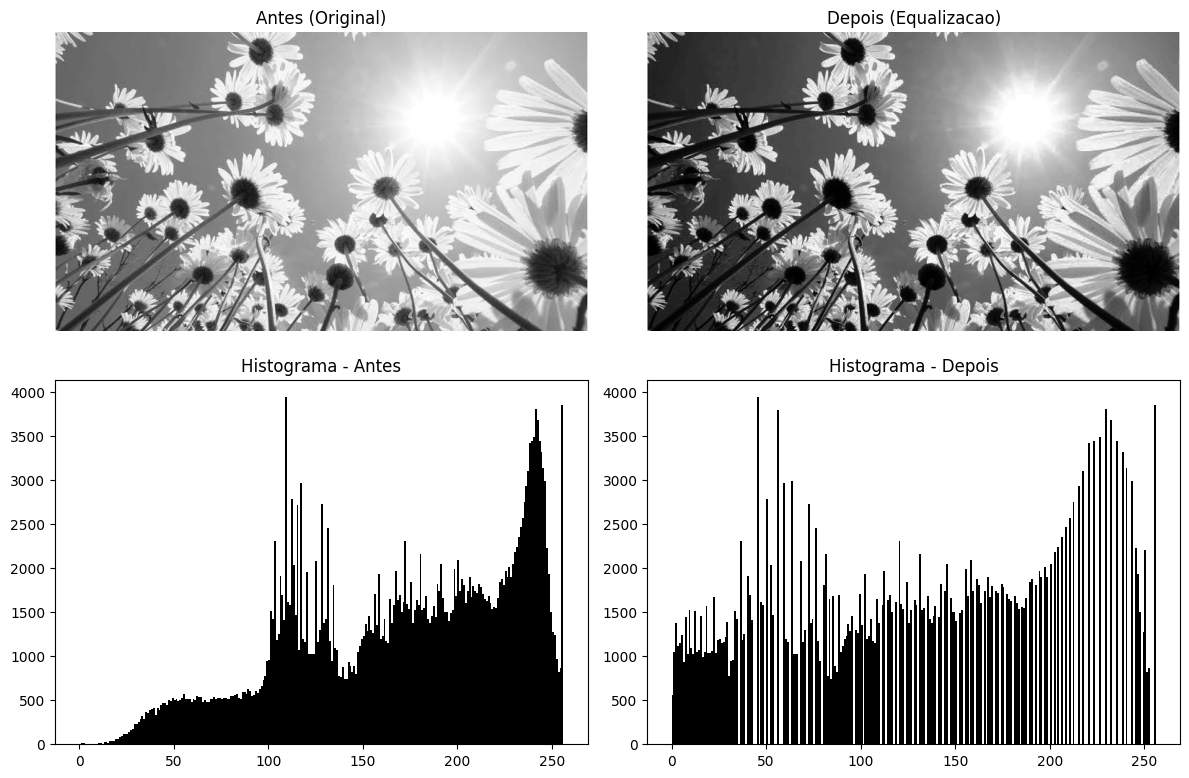

In [6]:
analisar_imagem('clara.jpg', operacao='equalizacao')

# Imagem 3 - Boa

/tmp/ipykernel_495/1729679174.py:40: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 0].hist(img_gray.ravel(), 256, [0,256], color='black')
/tmp/ipykernel_495/1729679174.py:43: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 1].hist(img_out.ravel(), 256, [0,256], color='black')


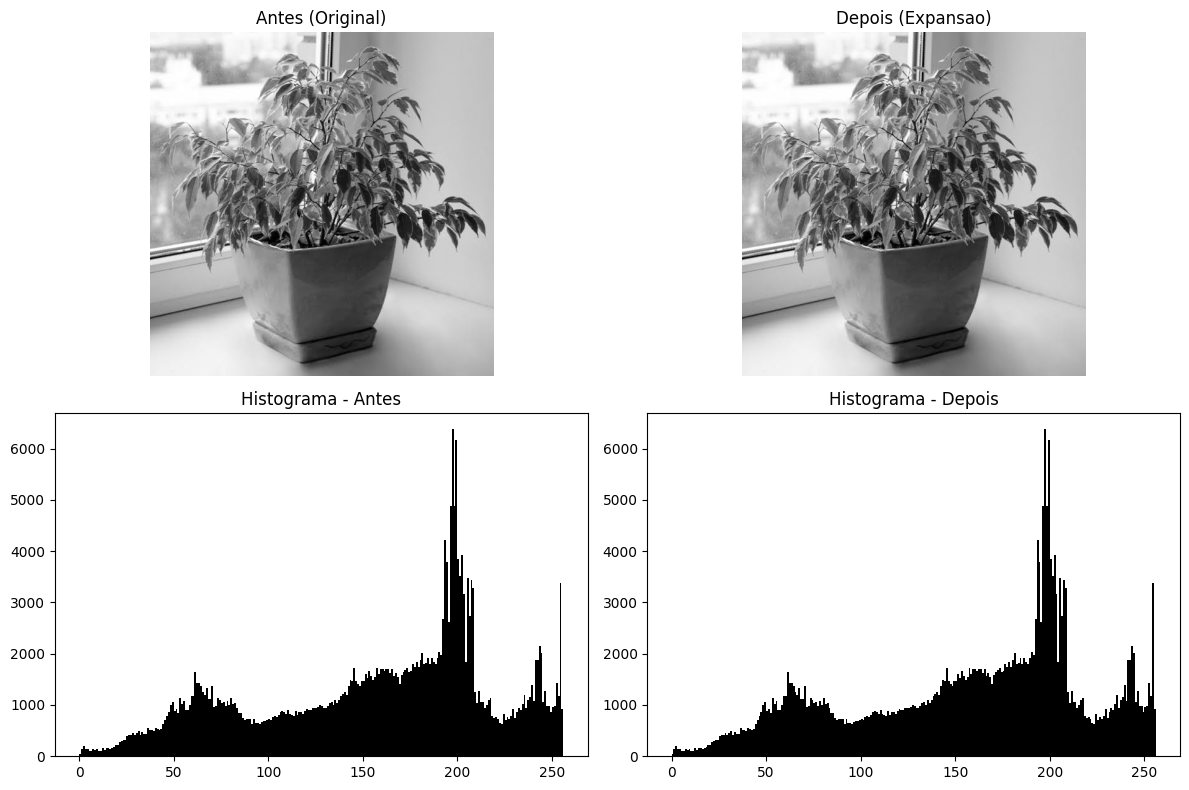

In [7]:
analisar_imagem('boa.jpg', operacao='expansao')